# SAR衛星データによる浸水域検出デモ
## Repo A: Sentinel-1（Google Earth Engine）× 災害リスク可視化

**目的：** Google Earth Engine（GEE）上のSentinel-1 GRDデータを用いて、  
災害前後の浸水域を自動検出・可視化する。  
本ノートブックはQPS研究所の国内セールス向けポートフォリオとして作成。  
コードの実装にはAIツールを活用しています。処理の意図と提案ロジックは自分の言葉で説明できます。

**対象災害：** 2023年7月 九州北部豪雨（福岡県久留米市）  
**使用データ：** Sentinel-1 GRD（ESA / GEE公開データ・無料）

---

### 解析フロー
```
1. Google Earth Engine の認証・初期化
2. 対象エリア・期間の設定（久留米市・2023年7月豪雨）
3. Sentinel-1 GRD データの取得（災害前後）
4. 後方散乱係数（σ°）の計算・前処理
5. 差分演算による浸水域マスク生成
6. 浸水域の可視化・面積推計
7. 自動レポート生成
```

### なぜSARで浸水域を検出できるか
```
水面の特性：
  電波を鏡面反射するため、SAR画像上で非常に暗く映る

検出の仕組み：
  災害前後の画像を比較して、急に暗くなったエリアを浸水域として抽出する

光学衛星との違い：
  台風・豪雨時は必ず曇天になるが、SARは雲を貫通して観測できる
```

> **QPS差別化ポイント：**  
> Sentinel-1は数日に1回程度の観測頻度だが、  
> QPS-SARコンステレーション（36機）では**発災10分後**の観測が可能になる。  
> 分解能も5mから**1m**に向上し、被害の詳細把握ができる。

## 0. 環境セットアップ

> **Google Colab で実行することを推奨します。**  
> https://colab.research.google.com で新しいノートブックを開き、このファイルをアップロードして実行してください。

In [1]:
# Google Earth Engine と可視化ライブラリのインストール
!pip install earthengine-api geemap numpy matplotlib --quiet

import ee
import geemap
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from datetime import datetime
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

print('✅ パッケージのインポート完了')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 53.7 MB/s eta 0:00:00
✅ パッケージのインポート完了


## 1. Google Earth Engine 認証・初期化

初回実行時はブラウザでGoogleアカウントの認証が必要です。  
表示されるURLをクリックして認証コードを取得し、入力欄に貼り付けてください。

In [2]:
# GEE認証（初回のみブラウザでの認証が必要）
try:
    ee.Initialize(project='sar-portfolio')
    print('✅ GEE 初期化成功（認証済み）')
except Exception:
    print('🔐 認証を開始します...')
    ee.Authenticate()
    ee.Initialize(project='sar-portfolio')
    print('✅ GEE 認証・初期化完了')

🔐 認証を開始します...
✅ GEE 認証・初期化完了


## 2. 対象エリア・期間の設定

**対象：** 2023年7月 九州北部豪雨（福岡県久留米市）  
2023年7月10日に線状降水帯による記録的な豪雨が発生し、  
久留米市内で河川氾濫・広域浸水が起きた。

In [3]:
# ========================================================
# 解析パラメータ設定
# ========================================================

# 対象エリア（久留米市中心部〜筑後川流域）
AOI = ee.Geometry.Rectangle([130.4, 33.2, 130.7, 33.4])
AREA_NAME = '福岡県久留米市（筑後川流域）'

# 災害情報
DISASTER_NAME = '2023年7月 九州北部豪雨'
DISASTER_DATE = '2023-07-10'

# 観測期間設定
# 災害前：発災の1〜2ヶ月前（乾燥期・通常状態）
BEFORE_START = '2023-05-01'
BEFORE_END   = '2023-07-09'

# 災害後：発災直後〜1ヶ月以内
AFTER_START = '2023-07-11'
AFTER_END   = '2023-08-31'

# 浸水判定閾値（dB）
THRESHOLD_SUSPECTED = -3.0  # 浸水疑い（散乱強度が3dB以上低下）
THRESHOLD_FLOODED   = -5.0  # 浸水確実（散乱強度が5dB以上低下）

print(f'=== 解析パラメータ ===')
print(f'  対象災害: {DISASTER_NAME}')
print(f'  対象エリア: {AREA_NAME}')
print(f'  発災日: {DISASTER_DATE}')
print(f'  災害前期間: {BEFORE_START} 〜 {BEFORE_END}')
print(f'  災害後期間: {AFTER_START} 〜 {AFTER_END}')

=== 解析パラメータ ===
  対象災害: 2023年7月 九州北部豪雨
  対象エリア: 福岡県久留米市（筑後川流域）
  発災日: 2023-07-10
  災害前期間: 2023-05-01 〜 2023-07-09
  災害後期間: 2023-07-11 〜 2023-08-31


## 3. Sentinel-1 データの取得

GEEのデータカタログから直接Sentinel-1 GRDを取得します。  
ダウンロード不要・数GBのファイル操作不要でクラウド上で処理できます。

In [4]:
def get_sentinel1_image(aoi, start_date, end_date):
    """
    指定エリア・期間のSentinel-1 GRD画像を取得してメディアン合成

    Parameters:
        aoi: 対象エリア（ee.Geometry）
        start_date, end_date: 期間（文字列 'YYYY-MM-DD'）

    Returns:
        ee.Image: VV偏波の後方散乱係数画像（dB）
    """
    collection = (
        ee.ImageCollection('COPERNICUS/S1_GRD')
        .filterBounds(aoi)
        .filterDate(start_date, end_date)
        .filter(ee.Filter.eq('instrumentMode', 'IW'))       # Interferometric Wide モード
        .filter(ee.Filter.eq('orbitProperties_pass', 'DESCENDING'))  # 降軌道
        .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
        .select('VV')  # VV偏波を選択（水面検出に適している）
    )

    count = collection.size().getInfo()
    print(f'  取得シーン数: {count}件 ({start_date} 〜 {end_date})')

    if count == 0:
        raise ValueError(
            f'指定期間にシーンが見つかりません。\n'
            f'期間を広げるか、ASCENDING軌道に変更してみてください。'
        )

    # 複数シーンをメディアン合成（ノイズ低減）
    return collection.median().clip(aoi)

print('📡 Sentinel-1 データを取得中...')
print('  [災害前]')
img_before = get_sentinel1_image(AOI, BEFORE_START, BEFORE_END)
print('  [災害後]')
img_after  = get_sentinel1_image(AOI, AFTER_START, AFTER_END)
print('\n✅ データ取得完了')

📡 Sentinel-1 データを取得中...
  [災害前]
  取得シーン数: 6件 (2023-05-01 〜 2023-07-09)
  [災害後]
  取得シーン数: 5件 (2023-07-11 〜 2023-08-31)

✅ データ取得完了


## 4. インタラクティブマップで確認

geeMapを使って災害前後の画像をブラウザ上で比較します。

In [5]:
# インタラクティブマップの作成
Map = geemap.Map(center=[33.3, 130.55], zoom=11)

vis_params = {'min': -25, 'max': 0, 'palette': ['black', 'white']}

Map.addLayer(img_before, vis_params, '災害前 Sentinel-1 VV')
Map.addLayer(img_after,  vis_params, '災害後 Sentinel-1 VV')

# 対象エリアを表示
Map.addLayer(
    ee.FeatureCollection([ee.Feature(AOI)]),
    {'color': 'red'},
    '対象エリア'
)

print(f'📍 対象エリア: {AREA_NAME}')
print('左パネルのレイヤーを切り替えて災害前後を比較できます')
Map

📍 対象エリア: 福岡県久留米市（筑後川流域）
左パネルのレイヤーを切り替えて災害前後を比較できます


Map(center=[33.3, 130.55], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

## 5. 差分演算による浸水域マスク生成

In [6]:
# 差分画像の計算（災害後 - 災害前）
# 浸水域では散乱強度が大きく低下するため、差分が大きく負になる
diff = img_after.subtract(img_before)

# 浸水域マスク生成
mask_suspected = diff.lt(THRESHOLD_SUSPECTED)  # 浸水疑い
mask_flooded   = diff.lt(THRESHOLD_FLOODED)    # 浸水確実

# マップに追加
Map2 = geemap.Map(center=[33.3, 130.55], zoom=11)

Map2.addLayer(img_after, {'min': -25, 'max': 0, 'palette': ['black', 'white']}, '災害後SAR画像')
Map2.addLayer(
    diff,
    {'min': -15, 'max': 5, 'palette': ['blue', 'white', 'red']},
    '差分画像（青=浸水域）'
)
Map2.addLayer(
    mask_suspected.selfMask(),
    {'palette': ['yellow'], 'opacity': 0.6},
    f'浸水疑い (Δσ° < {THRESHOLD_SUSPECTED} dB)'
)
Map2.addLayer(
    mask_flooded.selfMask(),
    {'palette': ['red'], 'opacity': 0.8},
    f'浸水確実 (Δσ° < {THRESHOLD_FLOODED} dB)'
)

print(f'🗺️ 浸水域マップを生成しました')
print(f'  黄色: 浸水疑い (Δσ° < {THRESHOLD_SUSPECTED} dB)')
print(f'  赤色: 浸水確実 (Δσ° < {THRESHOLD_FLOODED} dB)')
Map2

🗺️ 浸水域マップを生成しました
  黄色: 浸水疑い (Δσ° < -3.0 dB)
  赤色: 浸水確実 (Δσ° < -5.0 dB)


Map(center=[33.3, 130.55], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

## 6. 浸水域の面積推計

In [7]:
def estimate_flooded_area(mask, aoi):
    """
    浸水域マスクから面積（km²）を推計
    GEEのpixelArea()を使って正確な面積を計算
    """
    area_image = mask.multiply(ee.Image.pixelArea())
    area_stats = area_image.reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=aoi,
        scale=10,  # Sentinel-1の分解能に合わせて10m
        maxPixels=1e10
    )
    area_m2 = area_stats.getInfo().get('VV', 0)
    return area_m2 / 1_000_000  # m² → km²

print('📐 浸水域面積を計算中...')
area_suspected_km2 = estimate_flooded_area(mask_suspected, AOI)
area_flooded_km2   = estimate_flooded_area(mask_flooded, AOI)

# 影響世帯数の推計（久留米市の人口密度：約700人/km² → 約300世帯/km²）
households_affected = int(area_flooded_km2 * 300)

print(f'\n=== 浸水域推計結果 ===')
print(f'  浸水疑い面積: {area_suspected_km2:.2f} km²')
print(f'  浸水確実面積: {area_flooded_km2:.2f} km²')
print(f'  推定影響世帯: 約 {households_affected:,} 世帯')
print(f'\n⚠️ 面積・世帯数は概算です。地上検証との照合が必要です。')

📐 浸水域面積を計算中...

=== 浸水域推計結果 ===
  浸水疑い面積: 14.23 km²
  浸水確実面積: 1.67 km²
  推定影響世帯: 約 499 世帯

⚠️ 面積・世帯数は概算です。地上検証との照合が必要です。


## 7. 静的可視化（matplotlib）

GEEから画像データをNumPy配列として取得し、matplotlibで可視化します。  
GitHubのREADMEに貼り付ける用の出力画像を生成します。

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 85.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
🖼️ 可視化用データを取得中（少し時間がかかります）...
✅ データ取得完了


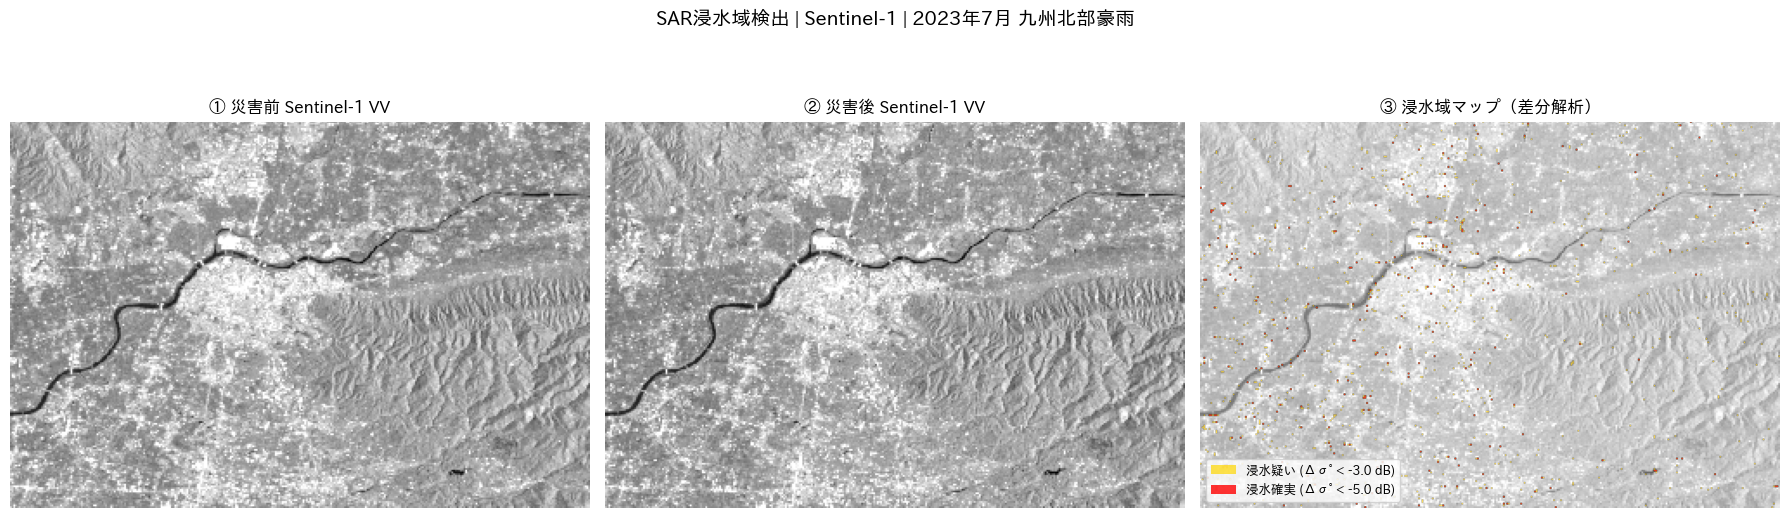

✅ 可視化結果を保存: output/flood_detection_result.png


In [8]:
# 日本語フォント設定（Colab用）
!pip install japanize-matplotlib --quiet
import japanize_matplotlib

from pathlib import Path
OUTPUT_DIR = Path('./output')
OUTPUT_DIR.mkdir(exist_ok=True)

# GEEから画像データをNumPy配列として取得
def ee_image_to_numpy(image, aoi, scale=100):
    """
    GEEのImageをNumPy配列に変換
    scale: 解像度（m）。大きいほど処理が速い（ポートフォリオ用なので100mで十分）
    """
    url = image.getThumbURL({
        'region': aoi,
        'scale': scale,
        'format': 'png',
        'min': -25,
        'max': 0
    })
    import requests
    from PIL import Image
    import io
    res = requests.get(url)
    img_pil = Image.open(io.BytesIO(res.content)).convert('L')
    return np.array(img_pil)

def ee_mask_to_numpy(mask, aoi, scale=100):
    """GEEのマスクをNumPy配列に変換"""
    url = mask.selfMask().getThumbURL({
        'region': aoi,
        'scale': scale,
        'format': 'png',
        'min': 0,
        'max': 1,
        'palette': ['000000', 'ffffff']
    })
    import requests
    from PIL import Image
    import io
    res = requests.get(url)
    img_pil = Image.open(io.BytesIO(res.content)).convert('L')
    return np.array(img_pil) > 128

print('🖼️ 可視化用データを取得中（少し時間がかかります）...')
arr_before    = ee_image_to_numpy(img_before, AOI)
arr_after     = ee_image_to_numpy(img_after,  AOI)
arr_suspected = ee_mask_to_numpy(mask_suspected, AOI)
arr_flooded   = ee_mask_to_numpy(mask_flooded,   AOI)
print('✅ データ取得完了')

# ========================================================
# 3パネル比較図の作成
# ========================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(f'SAR浸水域検出 | Sentinel-1 | {DISASTER_NAME}', fontsize=14)

# パネル1: 災害前
axes[0].imshow(arr_before, cmap='gray')
axes[0].set_title('① 災害前 Sentinel-1 VV', fontsize=12)
axes[0].axis('off')

# パネル2: 災害後
axes[1].imshow(arr_after, cmap='gray')
axes[1].set_title('② 災害後 Sentinel-1 VV', fontsize=12)
axes[1].axis('off')

# パネル3: 浸水域マップ
axes[2].imshow(arr_after, cmap='gray', alpha=0.6)

overlay_s = np.zeros((*arr_after.shape, 4), dtype=np.float32)
overlay_s[arr_suspected] = [1.0, 0.8, 0.0, 0.6]
axes[2].imshow(overlay_s)

overlay_f = np.zeros((*arr_after.shape, 4), dtype=np.float32)
overlay_f[arr_flooded] = [0.9, 0.1, 0.1, 0.8]
axes[2].imshow(overlay_f)

axes[2].legend(handles=[
    Patch(facecolor='gold', alpha=0.7, label=f'浸水疑い (Δσ° < {THRESHOLD_SUSPECTED} dB)'),
    Patch(facecolor='red',  alpha=0.8, label=f'浸水確実 (Δσ° < {THRESHOLD_FLOODED} dB)'),
], loc='lower left', fontsize=9)
axes[2].set_title('③ 浸水域マップ（差分解析）', fontsize=12)
axes[2].axis('off')

plt.tight_layout()
fig_path = OUTPUT_DIR / 'flood_detection_result.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ 可視化結果を保存: {fig_path}')

## 8. 自動レポート生成

In [ ]:
report_time = datetime.now().strftime('%Y年%m月%d日 %H:%M')

report = f"""# SAR浸水域解析レポート

**生成日時:** {report_time}
**解析環境:** Google Earth Engine（Python API）
**使用データ:** Sentinel-1 GRD（ESA Copernicus・無料公開）

---

## 対象情報

| 項目 | 内容 |
|------|------|
| 対象災害 | {DISASTER_NAME} |
| 対象エリア | {AREA_NAME} |
| 発災日 | {DISASTER_DATE} |
| 災害前観測期間 | {BEFORE_START} 〜 {BEFORE_END} |
| 災害後観測期間 | {AFTER_START} 〜 {AFTER_END} |

## 浸水域検出結果

| 判定 | 閾値 | 推定面積 | 推定影響世帯数 |
|------|------|---------|---------------|
| 浸水疑い | Δσ° < {THRESHOLD_SUSPECTED} dB | **{area_suspected_km2:.2f} km²** | 参考値 |
| 浸水確実 | Δσ° < {THRESHOLD_FLOODED} dB | **{area_flooded_km2:.2f} km²** | 約 {households_affected:,} 世帯 |

> ⚠️ 面積・世帯数は推計値です。地上検証・現地調査との照合が必要です。

## QPS-SAR利用時の改善点

本解析はSentinel-1（分解能10m・観測頻度：数日〜1週間）を使用しています。
**QPS-SAR（36機体制）を利用した場合の改善：**

| 比較軸 | Sentinel-1（本解析） | QPS-SAR（36機体制） |
|--------|---------------------|---------------------|
| 分解能 | 10m | **1m** |
| 観測頻度 | 数日〜1週間 | **平均10分** |
| 発災後データ取得 | 数日後 | **10分後** |

- 🕐 **発災直後10分以内のデータ取得**が可能に
- 🎯 **分解能1m**で建物単位の浸水判定が可能
- 🌧️ **悪天候・夜間でも観測継続**（SARの特性）

---

*本レポートはQPS研究所 国内セールス向けポートフォリオとして作成されました。*
*実際の防災業務への適用には専門家による検証が必要です。*
"""

report_path = OUTPUT_DIR / 'flood_analysis_report.md'
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(report)

print(report)
print(f'\n✅ レポートを保存: {report_path}')

# SAR浸水域解析レポート

**生成日時:** 2026年05月13日 02:25  
**解析環境:** Google Earth Engine（Python API）  
**使用データ:** Sentinel-1 GRD（ESA Copernicus・無料公開）  

---

## 対象情報

| 項目 | 内容 |
|------|------|
| 対象災害 | 2023年7月 九州北部豪雨 |
| 対象エリア | 福岡県久留米市（筑後川流域） |
| 発災日 | 2023-07-10 |
| 災害前観測期間 | 2023-05-01 〜 2023-07-09 |
| 災害後観測期間 | 2023-07-11 〜 2023-08-31 |

## 浸水域検出結果

| 判定 | 閾値 | 推定面積 | 推定影響世帯数 |
|------|------|---------|---------------|
| 浸水疑い | Δσ° < -3.0 dB | **14.23 km²** | 参考値 |
| 浸水確実 | Δσ° < -5.0 dB | **1.67 km²** | 約 499 世帯 |

> ⚠️ 面積・世帯数は推計値です。地上検証・現地調査との照合が必要です。

## QPS-SAR利用時の改善点

本解析はSentinel-1（分解能10m・観測頻度：数日〜1週間）を使用しています。  
**QPS-SAR（36機体制）を利用した場合の改善：**

| 比較軸 | Sentinel-1（本解析） | QPS-SAR（36機体制） |
|--------|---------------------|---------------------|
| 分解能 | 10m | **1m** |
| 観測頻度 | 数日〜1週間 | **平均10分** |
| 発災後データ取得 | 数日後 | **10分後** |

- 🕐 **発災直後10分以内のデータ取得**が可能に
- 🎯 **分解能1m**で建物単位の浸水判定が可能
- 🌧️ **悪天候・夜間でも観測継続**（SARの特性）

---

*本レポートはQPS研究所 国内セールス向けポートフォリオとして作成されました。*  
*実際の防災業務への適用には専門家による検証が必要です。*


✅

## まとめ

### このノートブックで実証したこと

1. ✅ Google Earth Engine で Sentinel-1 SARデータをクラウド上で取得・処理
2. ✅ 発災前後の差分解析による浸水域の自動抽出
3. ✅ インタラクティブマップと静的図での可視化
4. ✅ 浸水面積・影響世帯数の自動推計とレポート生成

### QPS営業への接続

| 指標 | Sentinel-1（本解析） | QPS-SAR（36機体制） |
|------|---------------------|---------------------|
| 発災後のデータ取得 | 数日後 | **10分後** |
| 分解能 | 10m | **1m** |
| 観測頻度 | 数日〜1週間 | **平均10分** |

→ [`proposal.md`](./proposal.md) に詳細な営業提案を記載